Integrantes: Andrés Álvarez
            Raul Barrera.
Ramo: Mineria de Datos: 004D

El proyecto que vamos a presentar es sobre los gastos militares que ha tenido cada continente a lo largo de los años. Ya que la dataset original que elegimos para trabajar era mucha informacion para trabajarla como nosotros queriamos, entonces a la data original la fuimos modificando, sacando algunos datos que no nos servian para trabajar, y se fue modificando y quitando datos y dejando solo los datos que queriamos trabajar. A lo largo de este dataset iremos explicando que datos trabajamos y como se trabjó esos datos.

Los datos que se consideró a ejecutar los analis son:

-Los continentes que son Europa, Norte America, Oceania, Sudamerica y Asia.

-El Monto que a invertido cada Continente.

-Los años donde para demostrar cuanto gasto cada continente vamos a considerar sus gastos en decadas.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [ ]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas (cuidado si el dataset es muy grande)
pd.set_option('display.max_rows', None)

In [ ]:
# Carga de datos
data_frame = pd.read_csv("/content/military-spending-sipri.csv", low_memory=False)
data_frame.head()


,Entity,Code,Year,Military expenditure,World region according to OWID
0,Afghanistan,AFG,1970,68814760.0,Asia
1,Afghanistan,AFG,1973,79796820.0,Asia
2,Afghanistan,AFG,1974,77561210.0,Asia
3,Afghanistan,AFG,1975,81419624.0,Asia
4,Afghanistan,AFG,1976,103842290.0,Asia


In [ ]:
data_frame.columns

Index(['Entity', 'Code', 'Year', 'Military expenditure',
       'World region according to OWID'],
      dtype='object')

Entity = Categorica
Code = Categorica
Year = Numerica
Military = Numerica
World = Categorica

In [ ]:
data_frame.shape


(9029, 5)

Tenemos 9029 filas y cinco columnas

In [ ]:
data_frame.isna().sum()

,0
Entity,0
Code,667
Year,0
Military expenditure,0
World region according to OWID,703


World region y code vamos a ignorarlos ya que es redundante tener columnas nulas

In [ ]:
data_frame_new = data_frame[['Entity', 'Year','Military expenditure']]
data_frame_new.head()
#Guardaremos un csv nuevo, limpio

,Entity,Year,Military expenditure
0,Afghanistan,1970,68814760.0
1,Afghanistan,1973,79796820.0
2,Afghanistan,1974,77561210.0
3,Afghanistan,1975,81419624.0
4,Afghanistan,1976,103842290.0


In [ ]:
data_frame_new.to_csv('military-spending-sipri_new.csv')

In [ ]:
# Carga de datos
data_frame_new = pd.read_csv("/content/military-spending-sipri_new.csv", low_memory=False)
data_frame_new.head()

,Unnamed: 0,Entity,Year,Military expenditure
0,0,Afghanistan,1970,68814760.0
1,1,Afghanistan,1973,79796820.0
2,2,Afghanistan,1974,77561210.0
3,3,Afghanistan,1975,81419624.0
4,4,Afghanistan,1976,103842290.0


Creamos un nuevo dataset con países, el año y el gasto militar de país de dicho año

In [ ]:
data_frame_new.shape

(9029, 4)

In [ ]:
data_frame_new['Year'].describe()

,Year
count,9029.000000
mean,1995.679256
std,18.919170
min,1949.000000
25%,1982.000000
50%,1998.000000
75%,2011.000000
max,2024.000000


In [ ]:
data_frame_new.isna().sum()

,0
Unnamed: 0,0
Entity,0
Year,0
Military expenditure,0


In [ ]:
import pandas as pd

# Usar el DataFrame original y copiarlo para no modificar el original
df_continent_expenditure = data_frame.copy()

# Renombrar la columna de región a Continente para mayor claridad
df_continent_expenditure.rename(columns={'World region according to OWID': 'Continent'}, inplace=True)

# Eliminar filas con valores nulos en Continente o Gasto Militar, ya que son esenciales para el análisis
df_continent_expenditure.dropna(subset=['Continent', 'Military expenditure'], inplace=True)

# Definir la función para asignar las décadas según lo solicitado
def assign_decade(year):
    if 1949 <= year <= 1959:
        return '1949-1959'
    elif 1960 <= year <= 1970:
        return '1960-1970'
    elif 1971 <= year <= 1981:
        return '1971-1981'
    elif 1982 <= year <= 1992:
        return '1982-1992'
    elif 1993 <= year <= 2003:
        return '1993-2003'
    elif 2004 <= year <= 2014:
        return '2004-2014'
    elif 2015 <= year <= 2024:
        return '2015-2024'
    else:
        return None # Excluir años fuera de las décadas especificadas

# Aplicar la función para crear la nueva columna 'Decade'
df_continent_expenditure['Decade'] = df_continent_expenditure['Year'].apply(assign_decade)

# Eliminar filas donde la década no pudo ser asignada (None)
df_continent_expenditure.dropna(subset=['Decade'], inplace=True)

# Agrupar por Continente y Década y sumar el 'Gasto militar'
df_grouped = df_continent_expenditure.groupby(['Continent', 'Decade'])['Military expenditure'].sum().reset_index()

# Renombrar la columna agregada para mayor claridad
df_grouped.rename(columns={'Military expenditure': 'Accumulated Military Expenditure'}, inplace=True)

# Para asegurar un orden lógico de las décadas, se crea una columna temporal para ordenar
df_grouped['Decade_Start_Year'] = df_grouped['Decade'].apply(lambda x: int(x.split('-')[0]))
df_grouped.sort_values(by=['Continent', 'Decade_Start_Year'], inplace=True)
df_grouped.drop(columns=['Decade_Start_Year'], inplace=True)

# El nuevo dataset resultante es df_grouped
new_dataset = df_grouped

# Mostrar las primeras filas del nuevo dataset
print(new_dataset.head())

  Continent     Decade  Accumulated Military Expenditure
0    Africa  1949-1959                      6.807208e+09
1    Africa  1960-1970                      8.482123e+10
2    Africa  1971-1981                      2.301397e+11
3    Africa  1982-1992                      2.226950e+11
4    Africa  1993-2003                      2.453837e+11


In [ ]:
new_dataset.to_csv('gasto_militar_por_decada_continente.csv', index=False)

Dado que el dataset "military-spending-sipri_new.csv cuenta con demasiadas filas, hemos decidido sintetizarlo. En resumen agruparemos los países por su continente respectivo y sumaremos el gasto militar de cada país por continente. Tambien agruparemos los años por decadas, es decir 1949-1959, 1960-1970, 1971-1981, etc.

In [ ]:
df_continente = pd.read_csv("/content/gasto_militar_por_decada_continente.csv", low_memory=False)
df_continente.head(10) #Visualizamos las primeras diez filas

,Continent,Decade,Accumulated Military Expenditure
0,Africa,1949-1959,6.807208e+09
1,Africa,1960-1970,8.482123e+10
2,Africa,1971-1981,2.301397e+11
3,Africa,1982-1992,2.226950e+11
4,Africa,1993-2003,2.453837e+11


In [ ]:
df_continente.tail()  #visualizamos las ultimas 5 filas

,Continent,Decade,Accumulated Military Expenditure
37,South America,1971-1981,3.328692e+11
38,South America,1982-1992,3.851175e+11
39,South America,1993-2003,3.806874e+11
40,South America,2004-2014,5.040966e+11
41,South America,2015-2024,5.281755e+11


In [ ]:
df_continente.shape #devuelve la cantidad de filas y columnas respectivamente

(42, 3)

In [ ]:
df_continente.dtypes #Aqui observamos los tipos de datos que tiene nuestra dataset

,0
Continent,object
Decade,object
Accumulated Military Expenditure,float64


In [ ]:
df_continente.isnull().sum() #En este punto estamos mostramos que nuestra dataset no tiene datos nulos

,0
Continent,0
Decade,0
Accumulated Military Expenditure,0


In [ ]:
df_continente.columns #mostramos los nombres de las columnas

Index(['Continent', 'Decade', 'Accumulated Military Expenditure'], dtype='object')

In [ ]:
df_continente.describe()

,Accumulated Military Expenditure
count,4.200000e+01
mean,2.341154e+12
std,2.924060e+12
min,6.807208e+09
25%,2.245562e+11
50%,4.833887e+11
75%,4.362688e+12
max,1.029596e+13


El gasto militar acumulado por continente y década muestra una enorme variabilidad, oscilando entre los 6.8 mil millones y los 10.3 billones de dólares.

In [ ]:
df_continente['Continent'].describe() #Aqui mostramos la cantidad total de continentes

,Continent
count,42
unique,6
top,Africa
freq,7


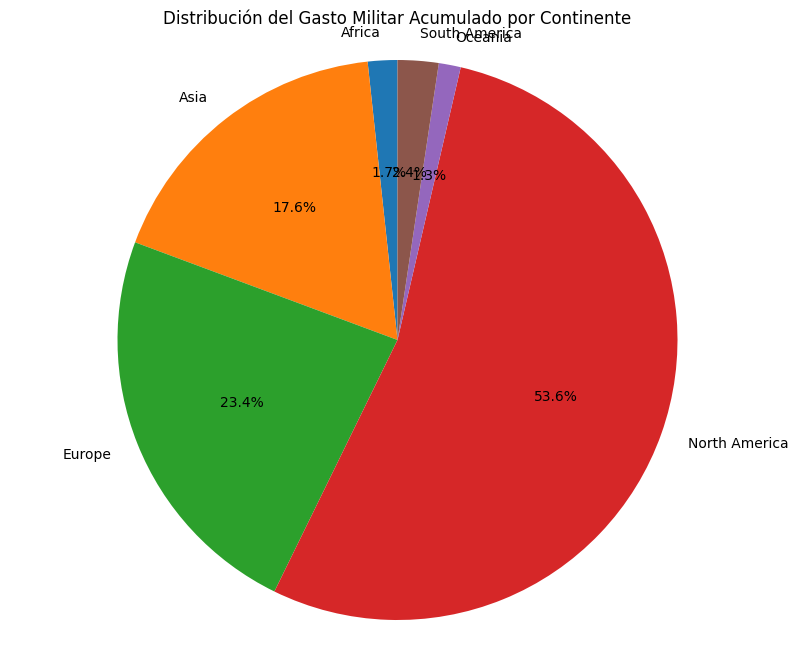

       Continent  Accumulated Military Expenditure
0         Africa                      1.675610e+12
1           Asia                      1.732982e+13
2         Europe                      2.303582e+13
3  North America                      5.272070e+13
4        Oceania                      1.246198e+12
5  South America                      2.320316e+12


In [ ]:
import matplotlib.pyplot as plt
#En este grafico se muestra la distribución acumulada de cada continente en gasto militar
resumen_continente = new_dataset.groupby('Continent')['Accumulated Military Expenditure'].sum().reset_index()


continente_res = resumen_continente['Continent'].values
conteo_res = resumen_continente['Accumulated Military Expenditure'].values


plt.figure(figsize=(10, 8))
plt.pie(conteo_res, labels=continente_res, autopct='%1.1f%%', startangle=90)
plt.title('Distribución del Gasto Militar Acumulado por Continente')
plt.axis('equal')
plt.show()

print(resumen_continente)

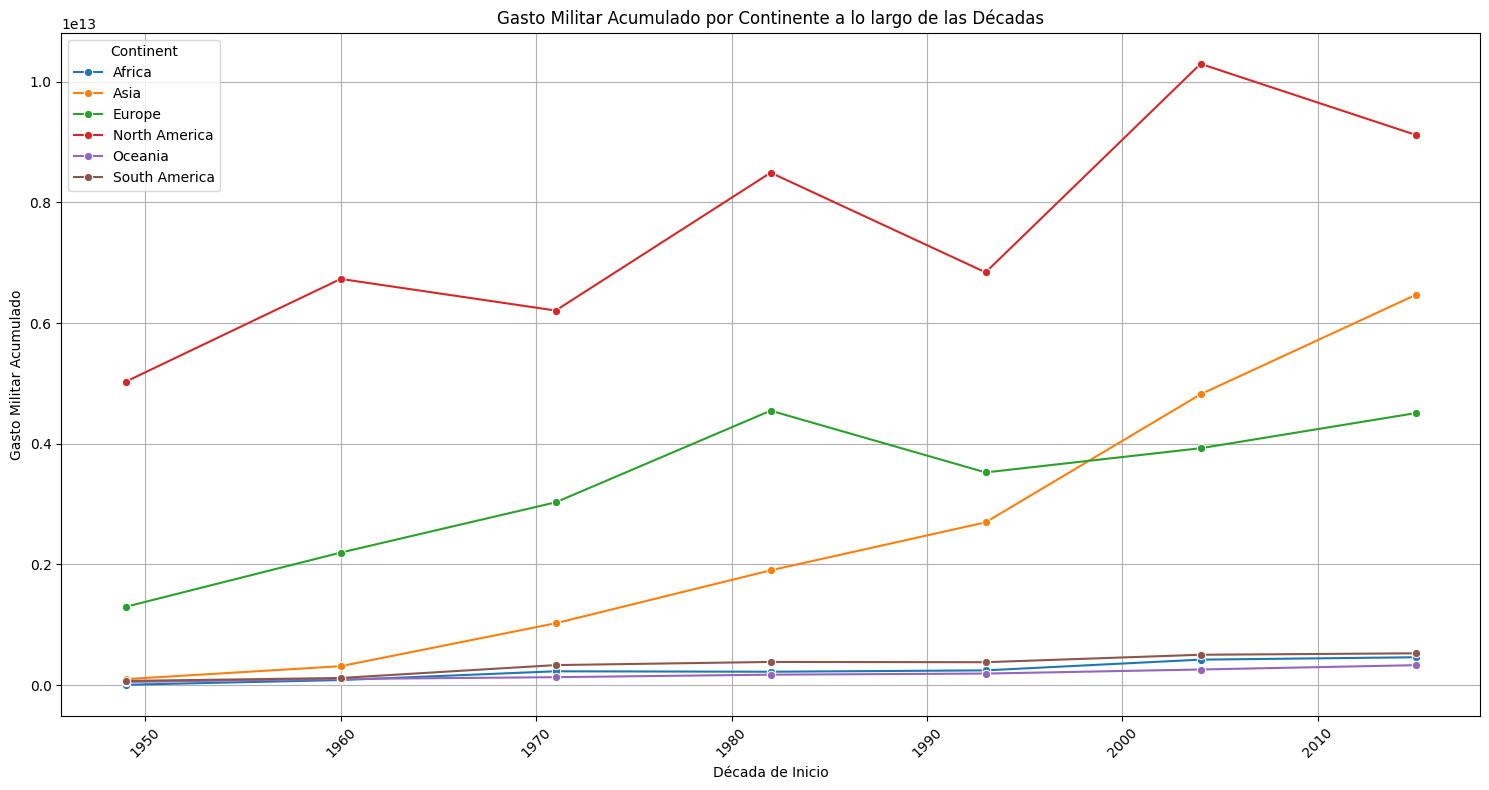

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# En este grafico se muestra el crecimiento del gasto militar por continente a lo largo de los años desde 1949 hasta 2024
df_continente['Decade_Start_Year'] = df_continente['Decade'].apply(lambda x: int(x.split('-')[0]))

plt.figure(figsize=(15, 8))
sns.lineplot(
    data=df_continente,
    x='Decade_Start_Year',
    y='Accumulated Military Expenditure',
    hue='Continent',
    marker='o'
)
plt.title('Gasto Militar Acumulado por Continente a lo largo de las Décadas')
plt.xlabel('Década de Inicio')
plt.ylabel('Gasto Militar Acumulado')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

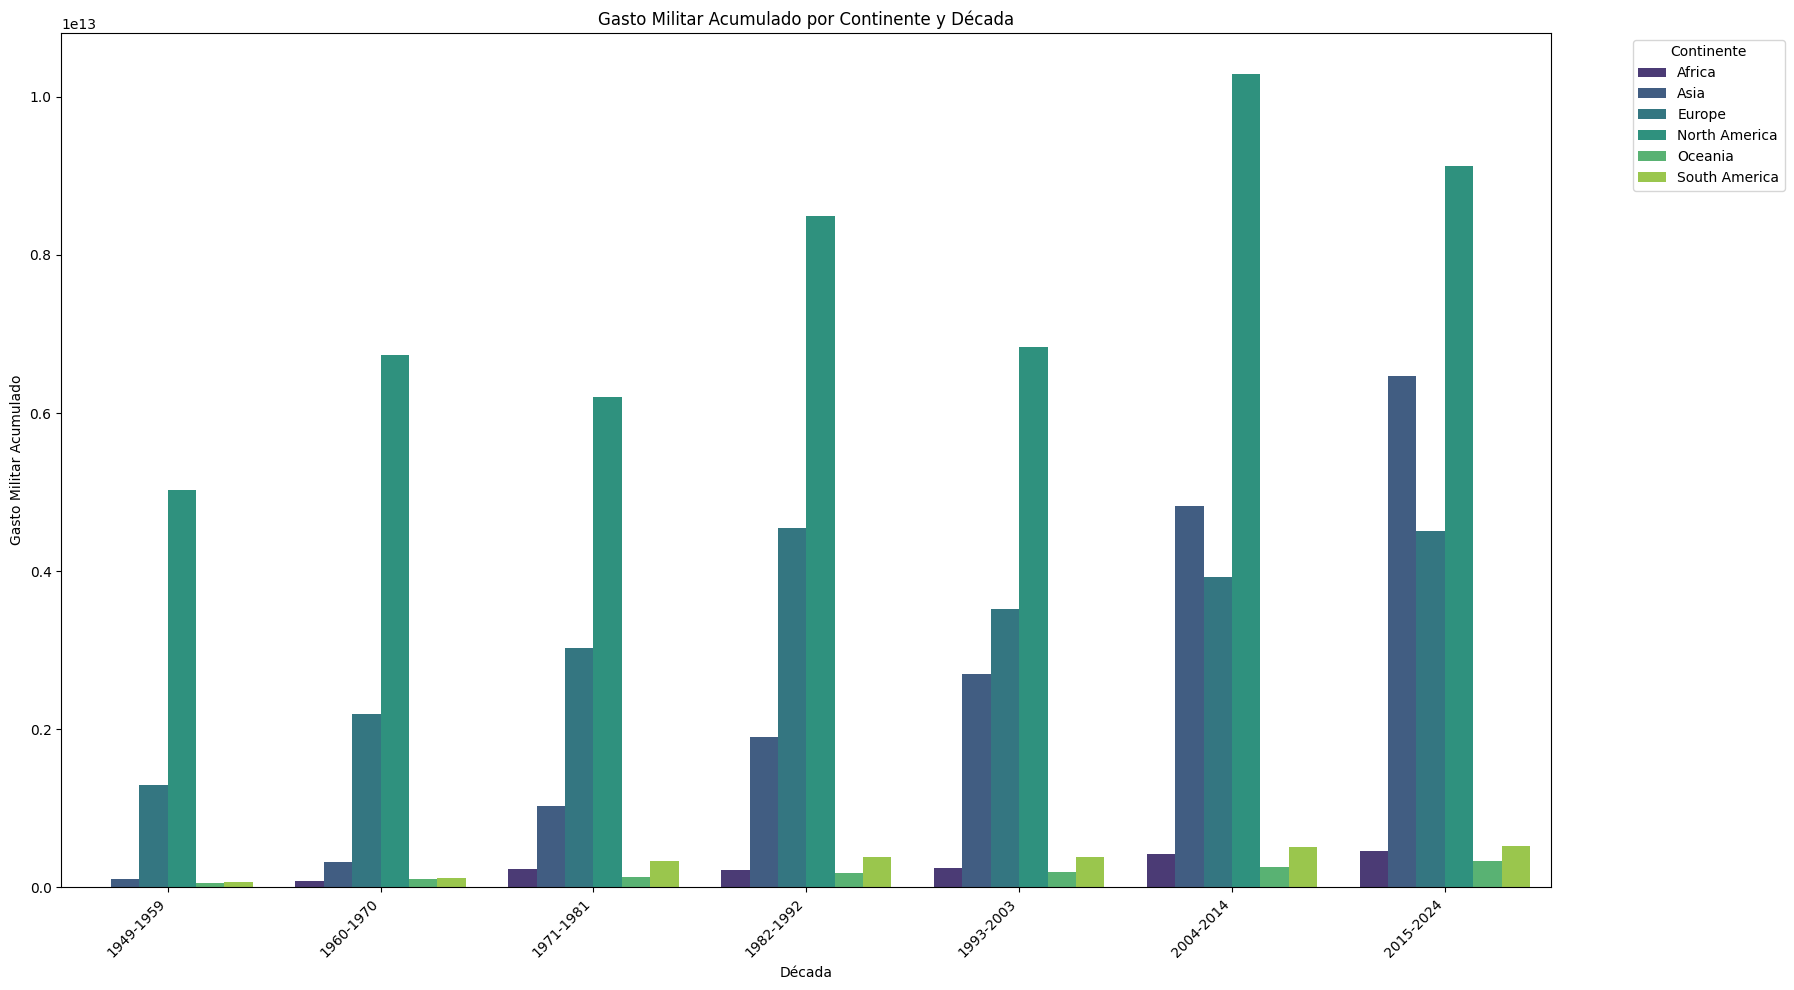

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# En este grafico nos muestra cuanto millones de dolares a inertvido cada continente en cada decada, que esto inicia desde 1949 hasta 2024


plt.figure(figsize=(18, 10))
sns.barplot(
    data=new_dataset,
    x='Decade',
    y='Accumulated Military Expenditure',
    hue='Continent',
    palette='viridis'
)
plt.title('Gasto Militar Acumulado por Continente y Década')
plt.xlabel('Década')
plt.ylabel('Gasto Militar Acumulado')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Continente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
#
ohe = OneHotEncoder(sparse_output=False)
entity_encoded = ohe.fit_transform(df_continente[['Continent']])

# Convertimos el resultado en un DataFrame con nombres de columnas claros
entity_df = pd.DataFrame(
    entity_encoded,
    columns=ohe.get_feature_names_out(['Continent']),
    index=df_continente.index
)

In [ ]:
df_finale = pd.concat([df_continente.drop(columns=['Continent']), entity_df], axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Definimos las columnas que queremos estandarizar en df_finale
cols_a_escalar = [
    'Accumulated Military Expenditure',
    'Decade_Start',
    'Decade_End',
    'Continent_Africa',
    'Continent_Asia',
    'Continent_Europe',
    'Continent_North America',
    'Continent_Oceania',
    'Continent_South America'
]

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Aplicamos el escalamiento a df_finale
df_finale_scaled = df_finale.copy()
df_finale_scaled[cols_a_escalar] = scaler.fit_transform(df_finale[cols_a_escalar])

# 4. Verificacion rapida
print("Primeras 5 filas con datos estandarizados de gasto militar, decadas y continentes:")
print(df_finale_scaled[cols_a_escalar].head())

Primeras 5 filas con datos estandarizados de gasto militar, decadas y continentes:
   Accumulated Military Expenditure  Decade_Start  Decade_End  \
0                         -0.808001          -1.5   -1.508075   
1                         -0.780997          -1.0   -1.003198   
2                         -0.730697          -0.5   -0.498320   
3                         -0.733274           0.0    0.006557   
4                         -0.725421           0.5    0.511434   

   Continent_Africa  Continent_Asia  Continent_Europe  \
0          2.236068       -0.447214         -0.447214   
1          2.236068       -0.447214         -0.447214   
2          2.236068       -0.447214         -0.447214   
3          2.236068       -0.447214         -0.447214   
4          2.236068       -0.447214         -0.447214   

   Continent_North America  Continent_Oceania  Continent_South America  
0                -0.447214          -0.447214                -0.447214  
1                -0.447214          -

El objetivo es estandarizar las características numéricas del dataset para preparar los datos para modelos de aprendizaje automático.

In [ ]:
df_finale[['Decade_Start', 'Decade_End']] = df_finale['Decade'].str.split('-', expand=True)
df_finale['Decade_Start'] = pd.to_numeric(df_finale['Decade_Start'])
df_finale['Decade_End'] = pd.to_numeric(df_finale['Decade_End'])
df_finale.head(100) #pendiente analisis de variable numerica y su distribucion

,Decade,Accumulated Military Expenditure,Decade_Start_Year,Continent_Africa,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America,Decade_Start,Decade_End
0,1949-1959,6.807208e+09,1949,1.0,0.0,0.0,0.0,0.0,0.0,1949,1959
1,1960-1970,8.482123e+10,1960,1.0,0.0,0.0,0.0,0.0,0.0,1960,1970
2,1971-1981,2.301397e+11,1971,1.0,0.0,0.0,0.0,0.0,0.0,1971,1981
3,1982-1992,2.226950e+11,1982,1.0,0.0,0.0,0.0,0.0,0.0,1982,1992
4,1993-2003,2.453837e+11,1993,1.0,0.0,0.0,0.0,0.0,0.0,1993,2003
5,2004-2014,4.230821e+11,2004,1.0,0.0,0.0,0.0,0.0,0.0,2004,2014
6,2015-2024,4.626808e+11,2015,1.0,0.0,0.0,0.0,0.0,0.0,2015,2024
7,1949-1959,1.000237e+11,1949,0.0,1.0,0.0,0.0,0.0,0.0,1949,1959
8,1960-1970,3.146220e+11,1960,0.0,1.0,0.0,0.0,0.0,0.0,1960,1970
9,1971-1981,1.026346e+12,1971,0.0,1.0,0.0,0.0,0.0,0.0,1971,1981


In [ ]:
#analisis de correlacion
df_finale_corr = df_finale.drop(columns=['Decade']).corr()


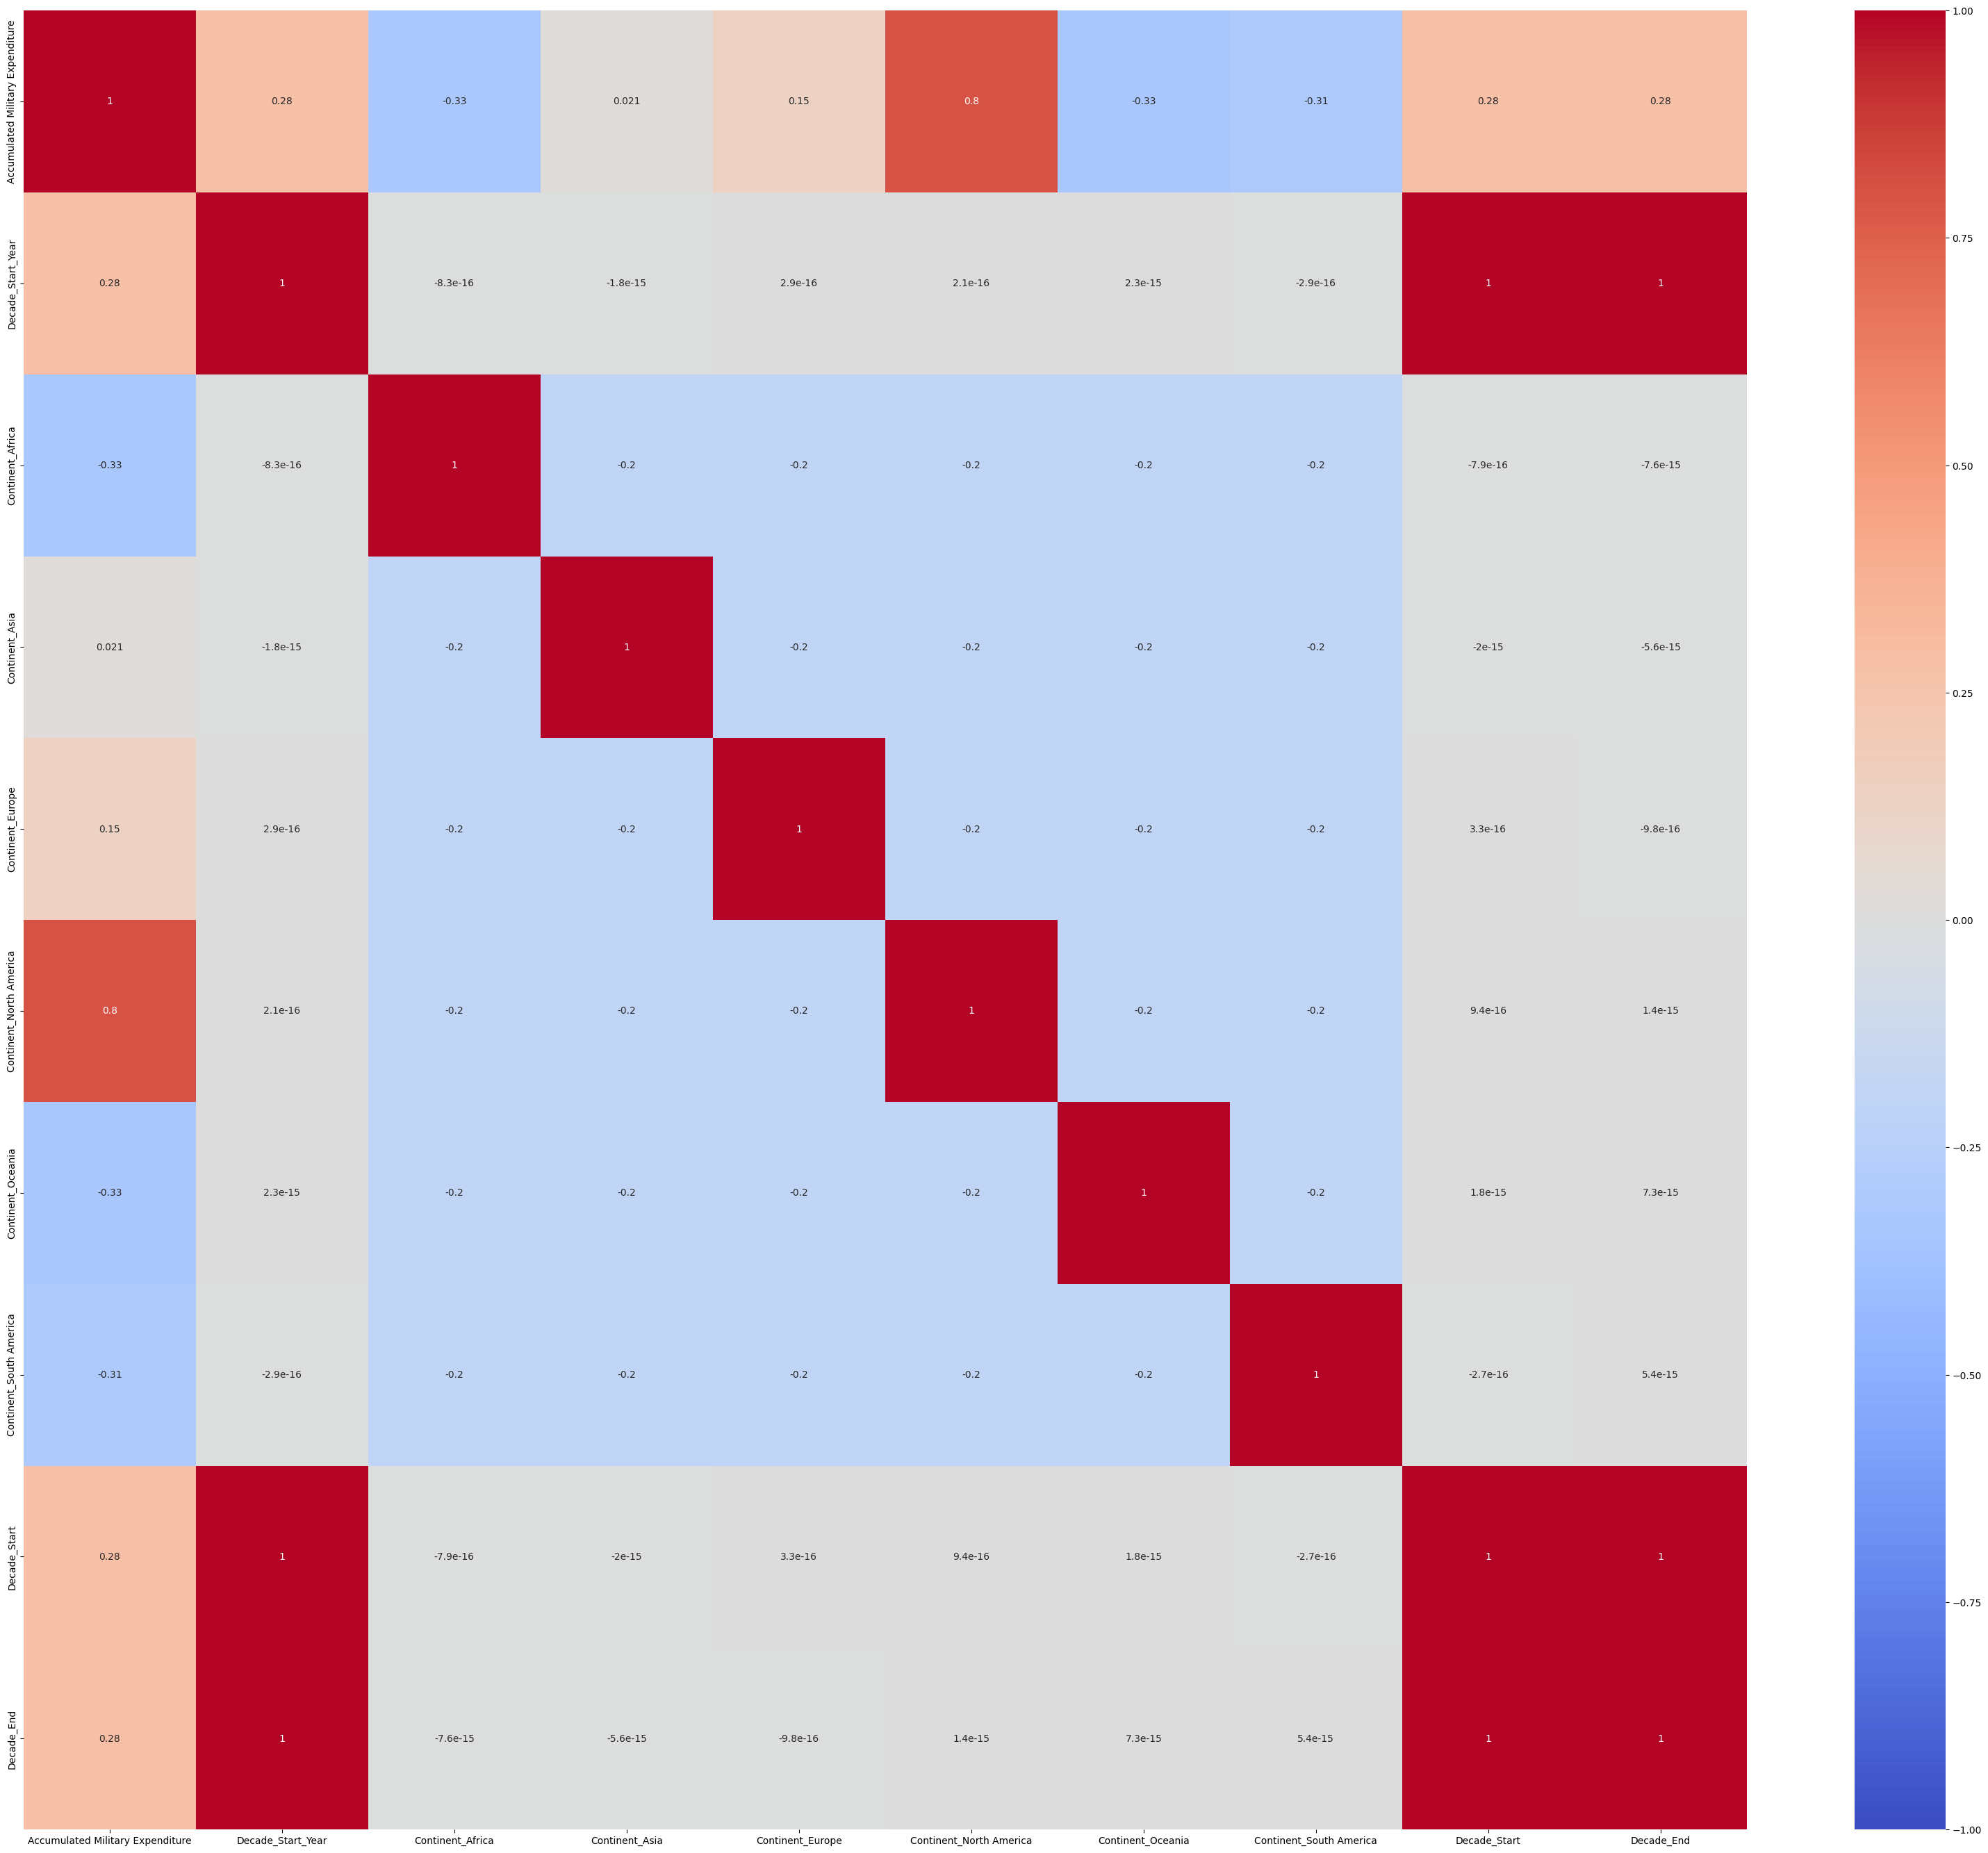

In [ ]:
corr_matrix = df_finale_corr

plt.figure(figsize=(40, 34))

sb.heatmap(corr_matrix, vmin=-1,vmax=+1,annot=True,cmap="coolwarm")

plt.show()